In [3]:
from pathlib import Path
import sys
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split

# Works whether Jupyter was started from the project root or att_N8/
cwd = Path.cwd().resolve()

if (cwd / "GenerateTraj").is_dir():
    project_dir = cwd
    experiment_dir = cwd / "att_N8"
elif (cwd.parent / "GenerateTraj").is_dir():
    project_dir = cwd.parent
    experiment_dir = cwd
else:
    raise RuntimeError("Could not find GenerateTraj/.")

sys.path.insert(0, str(experiment_dir))

from dataset import SingleNTrajectoryDataset
from model import TrajectoryGRUMDN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cpu


In [2]:
data_dir = project_dir / "GenerateTraj" / "data" / "sz_N8"
files = sorted(data_dir.glob("trajectory_*.npy"))

if not files:
    raise FileNotFoundError(f"No trajectory files found in {data_dir}")

sz = np.stack([np.load(path) for path in files]).astype(np.float32)

print("Number of trajectories:", len(sz))
print("Array shape:", sz.shape)  # expected: (1000, 210)
print("Value range:", sz.min(), sz.max())

Number of trajectories: 1000
Array shape: (1000, 210)
Value range: -1.0 0.45446378


In [3]:
dataset = SingleNTrajectoryDataset(sz)

n_total = len(dataset)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

split_generator = torch.Generator().manual_seed(42)

train_set, val_set, test_set = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=split_generator,
)

batch_size = 64
pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_set, batch_size=batch_size, shuffle=True, pin_memory=pin_memory
)
val_loader = DataLoader(
    val_set, batch_size=batch_size, shuffle=False, pin_memory=pin_memory
)
test_loader = DataLoader(
    test_set, batch_size=batch_size, shuffle=False, pin_memory=pin_memory
)

x_batch, y_batch = next(iter(train_loader))
print("Input batch:", x_batch.shape)   # (64, 209, 2)
print("Target batch:", y_batch.shape)  # (64, 209)

Input batch: torch.Size([64, 209, 2])
Target batch: torch.Size([64, 209])


In [50]:
# Cell 4 — create the GRU–MDN
torch.manual_seed(42)

model = TrajectoryGRUMDN(
    input_size=2,
    hidden_size=128,
    num_layers=2,
    mixtures=5,
    dropout=0.1,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-5,
)

print(model)

TrajectoryGRUMDN(
  (gru): GRU(2, 128, num_layers=2, batch_first=True, dropout=0.1)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=15, bias=True)
  )
)


In [51]:
def mdn_nll(target, logits, means, scales):
    """
    target: (batch, sequence_length)
    logits, means, scales: (batch, sequence_length, mixtures)
    """
    target = target.unsqueeze(-1)  # (batch, sequence_length, 1)

    log_component_probability = (
        -0.5 * ((target - means) / scales).square()
        - torch.log(scales)
        - 0.5 * math.log(2.0 * math.pi)
    )

    log_mixture_probability = torch.logsumexp(
        torch.log_softmax(logits, dim=-1) + log_component_probability,
        dim=-1,
    )

    return -log_mixture_probability.mean()

In [52]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0.0
    total_trajectories = 0

    for features, delta_sz in loader:
        features = features.to(device, non_blocking=True)
        delta_sz = delta_sz.to(device, non_blocking=True)

        logits, means, scales, _ = model(features)
        loss = mdn_nll(delta_sz, logits, means, scales)

        batch_count = features.shape[0]
        total_loss += loss.item() * batch_count
        total_trajectories += batch_count

    return total_loss / total_trajectories

In [53]:
epochs = 100
best_val_loss = float("inf")
train_losses = []
val_losses = []

checkpoint_path = experiment_dir / "n8_grumdn_best.pt"

for epoch in range(1, epochs + 1):
    model.train()
    total_train_loss = 0.0
    total_trajectories = 0

    for features, delta_sz in train_loader:
        features = features.to(device, non_blocking=True)
        delta_sz = delta_sz.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits, means, scales, _ = model(features)
        loss = mdn_nll(delta_sz, logits, means, scales)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_count = features.shape[0]
        total_train_loss += loss.item() * batch_count
        total_trajectories += batch_count

    train_loss = total_train_loss / total_trajectories
    val_loss = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "validation_nll": val_loss,
                "model_config": {
                    "input_size": 2,
                    "hidden_size": 128,
                    "num_layers": 2,
                    "mixtures": 5,
                },
            },
            checkpoint_path,
        )

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d}/{epochs} | "
            f"train NLL: {train_loss:.5f} | "
            f"validation NLL: {val_loss:.5f}"
        )

print(f"Best validation NLL: {best_val_loss:.5f}")
print(f"Saved checkpoint: {checkpoint_path}")

Epoch   1/100 | train NLL: 0.53290 | validation NLL: 0.47945
Epoch  10/100 | train NLL: -1.19389 | validation NLL: -1.25697
Epoch  20/100 | train NLL: -1.23702 | validation NLL: -1.29255
Epoch  30/100 | train NLL: -1.24851 | validation NLL: -1.21546
Epoch  40/100 | train NLL: -1.25712 | validation NLL: -1.33424
Epoch  50/100 | train NLL: -1.26498 | validation NLL: -1.30274
Epoch  60/100 | train NLL: -1.27101 | validation NLL: -1.27017
Epoch  70/100 | train NLL: -1.28413 | validation NLL: -1.28786
Epoch  80/100 | train NLL: -1.31802 | validation NLL: -1.35498
Epoch  90/100 | train NLL: -1.32091 | validation NLL: -1.36706
Epoch 100/100 | train NLL: -1.32113 | validation NLL: -1.34703
Best validation NLL: -1.37106
Saved checkpoint: /gpfs01/work/nikital/projects/deep_learning/study_trajectories_1/att_N8/n8_grumdn_best.pt


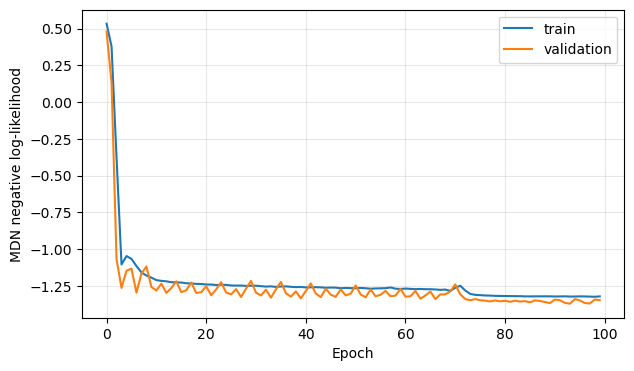

In [54]:
# Cell 8 — plot the learning curves
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="validation")
plt.xlabel("Epoch")
plt.ylabel("MDN negative log-likelihood")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [55]:
# Cell 9 — evaluate the best saved model once on the held-out test data
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])

test_loss = evaluate(test_loader)

print("Best checkpoint epoch:", checkpoint["epoch"])
print(f"Test NLL: {test_loss:.5f}")

Best checkpoint epoch: 94
Test NLL: -1.38820


In [56]:
from torch.distributions import Categorical, Normal

@torch.no_grad()
def generate_trajectory(model, n_time_points=210, initial_sz=-1.0):
    model.eval()

    normalized_times = torch.linspace(0.0, 1.0, n_time_points - 1)
    generated_sz = [initial_sz]
    current_sz = initial_sz
    hidden = None

    for time_value in normalized_times:
        features = torch.tensor(
            [[[current_sz, time_value.item()]]],
            dtype=torch.float32,
            device=device,
        )  # shape: (1, 1, 2)

        logits, means, scales, hidden = model(features, hidden)

        component = Categorical(logits=logits[0, 0]).sample()
        delta_sz = Normal(
            means[0, 0, component],
            scales[0, 0, component],
        ).sample().item()

        current_sz = current_sz + delta_sz
        generated_sz.append(current_sz)

    return np.array(generated_sz, dtype=np.float32)

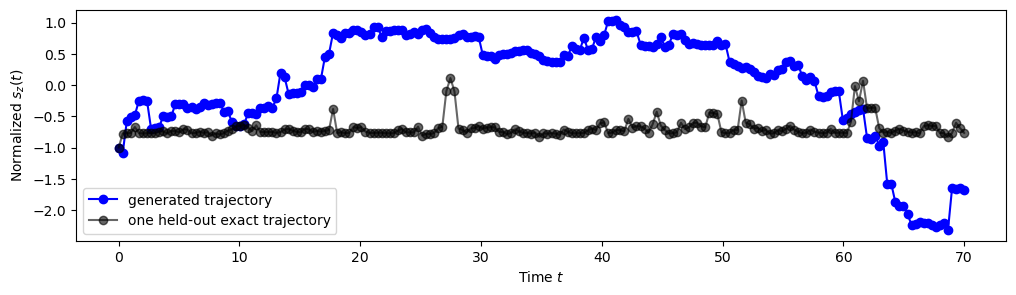

In [57]:
# Generate and plot one new stochastic trajectory
torch.manual_seed(4)  # Change or remove this line for another random sample.

generated_sz = generate_trajectory(model)
physical_time = np.linspace(0.0, 70.0, len(generated_sz))

plt.figure(figsize=(12, 3))
plt.plot(physical_time, generated_sz, 'b-o', label="generated trajectory")

# Optional: compare to one held-out exact trajectory.
reference_index = test_set.indices[0]
plt.plot(
    physical_time,
    sz[reference_index],
    'k-o',
    alpha=0.6,
    label="one held-out exact trajectory",
)

plt.xlabel(r"Time $t$")
plt.ylabel(r"Normalized $s_z(t)$")
plt.legend()
plt.show()

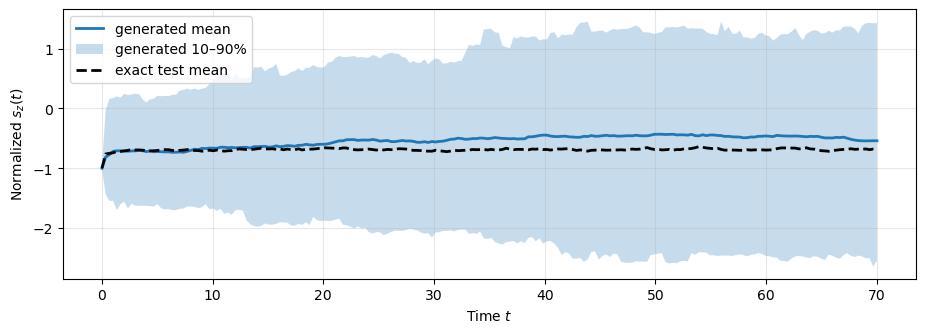

In [58]:
generated_ensemble = np.stack(
    [generate_trajectory(model) for _ in range(100)]
)

test_indices = np.array(test_set.indices)
exact_test_mean = sz[test_indices].mean(axis=0)

plt.figure(figsize=(11, 3.5))
plt.plot(physical_time, generated_ensemble.mean(axis=0), lw=2, label="generated mean")
plt.fill_between(
    physical_time,
    np.percentile(generated_ensemble, 10, axis=0),
    np.percentile(generated_ensemble, 90, axis=0),
    alpha=0.25,
    label="generated 10–90%",
)
plt.plot(physical_time, exact_test_mean, "k--", lw=2, label="exact test mean")
plt.xlabel(r"Time $t$")
plt.ylabel(r"Normalized $s_z(t)$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
generated_ensemble = np.stack(
    [generate_trajectory(model) for _ in range(100)]
)

test_indices = np.array(test_set.indices)
exact_test_mean = sz[test_indices].mean(axis=0)

plt.figure(figsize=(11, 3.5))
plt.plot(physical_time, generated_ensemble.mean(axis=0), lw=2, label="generated mean")
plt.fill_between(
    physical_time,
    np.percentile(generated_ensemble, 10, axis=0),
    np.percentile(generated_ensemble, 90, axis=0),
    alpha=0.25,
    label="generated 10–90%",
)
plt.plot(physical_time, exact_test_mean, "k--", lw=2, label="exact test mean")
plt.xlabel(r"Time $t$")
plt.ylabel(r"Normalized $s_z(t)$")
plt.grid(alpha=0.3)
plt.legend()
plt.ylim(-1,0)
plt.show()

In [ ]:
#RNN but make a grid and do categorial distribution over grid points 

#Bounded 

In [2]:
#Train and test at all data 
# give it 50 % of trajectory and see if it can continue

In [ ]:
# Neural PDE 